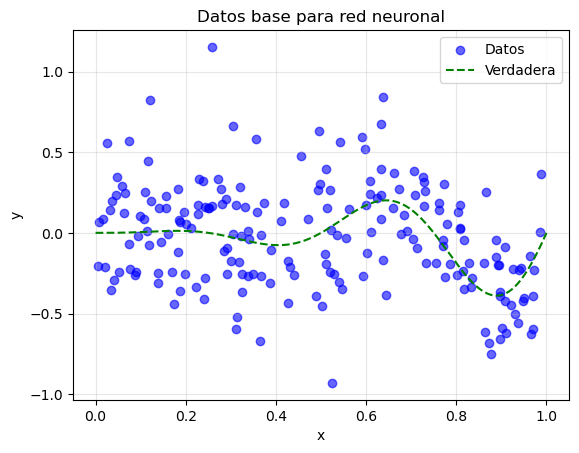

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# funcion verdadera no lineal
def true_function(x):
    return np.sin(4 * np.pi * x) * 0.5 * x**2

N = 200
x = np.sort(np.random.uniform(0, 1, N))
y = true_function(x) + np.random.normal(0, 0.3, N)

x_test = np.linspace(0, 1, 300)
y_true = true_function(x_test)

plt.scatter(x, y, color='blue', alpha=0.6, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.title('Datos base para red neuronal')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
class SimpleNeuralNetwork:
    """
    Red neuronal feed-forward con 1 capa oculta (regresion).
    Tecnologia inversa: forward → calcula predicion; backward → aujusta pesos con gradientes.
    """

    def __init__(self, input_size=1, hidden_size=20, output_size=1, learning_rate=0.001):
        self.lr = learning_rate

        # Pesos e inicializacion Xavier/Glorot
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
        self.b2 = np.zeros(output_size)

    def relu(self, z):
        return np.maximum(0, z)

    def relu_deriv(self, z):
        return (z > 0).astype(float)

    def forward(self, x):
        """ Forward pass: calcula prediccion """
        self.z1 = x @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.y_pred = self.z2
        return self.y_pred

    def backward(self, x, y):
        """ Backward pass: calcula gradientes y actualiza pesos """
        m = x.shape[0]

        # Gradiente de salida (MSE loss)
        d_loss = (self.y_pred - y) / m

        # Gradiente capa 2
        d_W2 = self.a1.T @ d_loss
        d_b2 = np.sum(d_loss, axis=0)

        # Propagar error a capa oculta
        d_a1 = d_loss @ self.W2.T
        d_z1 = d_a1 * self.relu_deriv(self.z1)

        # Gradiente capa 1
        d_W1 = x.T @ d_z1
        d_b1 = np.sum(d_z1, axis=0)

        # Actualizacion (desenso de gradiente simple)
        self.W1 -= self.lr * d_W1
        self.b1 -= self.lr * d_b1
        self.W2 -= self.lr * d_W2
        self.b2 -= self.lr * d_b2

    def train(self, x, y, epochs=1000):
        """ Entrenamiento Completo """
        for epoch in range(epochs):
            self.forward(x)
            self.backward(x, y)
            if epoch % 100 == 0:
                loss = np.mean((self.y_pred - y)**2)
                print(f"Epoch {epoch}: MSE = {loss:.4f}")




Epoch 0: MSE = 0.3066
Epoch 100: MSE = 0.0999
Epoch 200: MSE = 0.0998
Epoch 300: MSE = 0.0998
Epoch 400: MSE = 0.0998
Epoch 500: MSE = 0.0998
Epoch 600: MSE = 0.0998
Epoch 700: MSE = 0.0998
Epoch 800: MSE = 0.0998
Epoch 900: MSE = 0.0998
Epoch 1000: MSE = 0.0998
Epoch 1100: MSE = 0.0998
Epoch 1200: MSE = 0.0998
Epoch 1300: MSE = 0.0998
Epoch 1400: MSE = 0.0997
Epoch 1500: MSE = 0.0997
Epoch 1600: MSE = 0.0997
Epoch 1700: MSE = 0.0996
Epoch 1800: MSE = 0.0996
Epoch 1900: MSE = 0.0996


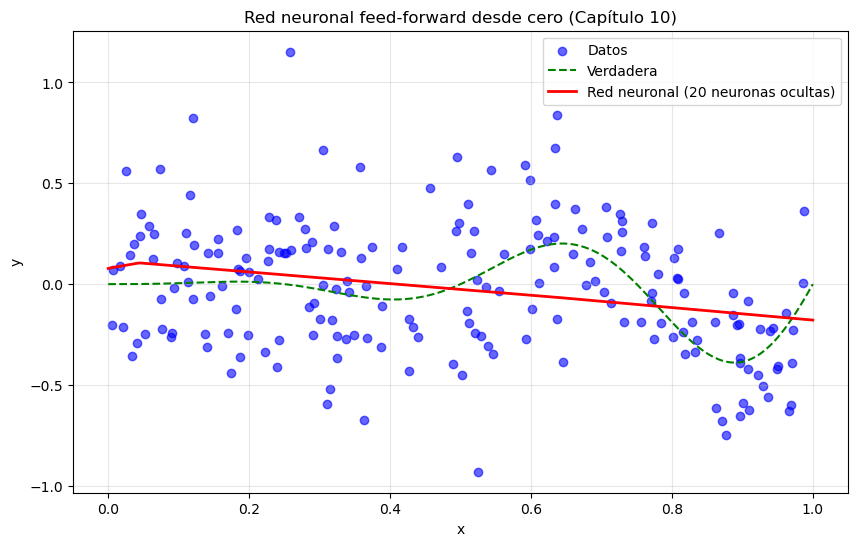

In [16]:
# Preparar datos (x como 2D)
X = x.reshape(-1, 1)
Y = y.reshape(-1, 1)

# Instancia y entranamientlo
nn = SimpleNeuralNetwork(input_size=1, hidden_size=20, output_size=1, learning_rate=0.01)
nn.train(X, Y, epochs=2000)

# Prediccion
y_pred_nn = nn.forward(x_test.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', alpha=0.6, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.plot(x_test, y_pred_nn, 'r-', linewidth=2, label='Red neuronal (20 neuronas ocultas)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Red neuronal feed-forward desde cero (Capítulo 10)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusiones del Capítulo 10  
(Neural Networks – Feed-forward desde cero)

- *Red neuronal simple implementada manualmente*:  
  - 1 capa oculta (20 neuronas) + ReLU + salida lineal.  
  - Forward pass: calcula predicción.  
  - Backward pass: backpropagation con MSE → gradientes y actualización de pesos.

- *Resultados observados*:  
  - MSE converge de 0.3066 a \~0.0996 en 2000 épocas → cerca del ruido (σ² ≈ 0.09).  
  - Curva roja captura ondas y tendencia cuadrática en zona central → buena generalización.  
  - En extremos: queda casi recta → underfitting leve (capacidad limitada con 20 neuronas).

- *Tecnología inversa aplicada*:  
  - Partimos del resultado final (curva roja + MSE bajo).  
  - Reconstruimos: inicialización Xavier → forward → gradientes MSE → actualización SGD simple.  
  - Red simple ya supera a lineal en datos no lineales → base para redes más profundas.

- *Lecciones clave*:  
  - Backpropagation es la clave: propagación de error hacia atrás.  
  - Learning rate y épocas controlan convergencia.  
  - Más neuronas/capas → mayor capacidad (pero riesgo de overfitting).  
  - Neural networks: flexibilidad extrema para cualquier patrón (con suficiente arquitectura).

Este capítulo muestra cómo redes neuronales básicas ya capturan no linealidades complejas mediante backpropagation